In [29]:
%load_ext autoreload
%autoreload 2

from preprocessing import (
    load_and_normalize, flatten_and_clahe, denoise_light,
    vesselness, make_fov_mask, binarize_V, split_by_radius_adaptive, vesselness_fusion_meij_jerman
)
print("OK: preprocessing importé depuis")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
OK: preprocessing importé depuis


In [31]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.filters import median
from tqdm import tqdm
from matplotlib.patches import FancyArrow
import cv2

In [33]:
# --- Paramètres globaux ---
start_id = 10001
end_id   = 10300

ROOT = Path(r"D:/projet PRIM")
INPUT_DIR = ROOT / r"OCTA 6mm/OCTA_6mm_part8/OCTA_6mm/Projection Maps/OCTA(ILM_OPL)"

patch_size  = 200
target_size = 256

SCAN_MM = 3.0   # mets 6.0 si tu traites des scans 6mm
SCALE    = SCAN_MM / 3.0

SIG_SMALL = (0.6 * SCALE, 1.6 * SCALE)   # pour capillaires
SIG_LARGE = (2.0 * SCALE, 4.0 * SCALE)   # pour gros vaisseaux
LARGE_METHOD = "jerman"                  # ou "frangi"

# --- Dossiers de sortie ---
OUT_ROOT = Path(r"D:\PRIM-Project\data\patches256_filtered")
subdirs = {
    "input_norm": OUT_ROOT / "input_norm",
    "flat_clahe": OUT_ROOT / "flat_clahe",
    "denoised"  : OUT_ROOT / "denoised",
    "v_small"   : OUT_ROOT / "v_small",
    "v_large"   : OUT_ROOT / "v_large",
    "v_fused"   : OUT_ROOT / "v_fused",
}

for d in subdirs.values():
    d.mkdir(parents=True, exist_ok=True)

print("Dossiers créés dans :", OUT_ROOT)

Dossiers créés dans : D:\PRIM-Project\data\patches256_filtered


Patch + filtrage + padding: 100%|████████████████████████████████████████████████████| 300/300 [10:35<00:00,  2.12s/it]


Terminé. Nombre total de patchs traités : 1200


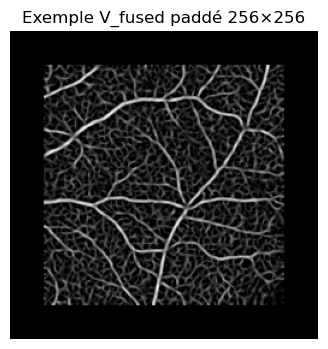

In [35]:
# Découpage en 4 patches 200x200
def patches_cv2(img: np.ndarray, patch=200):
    """
    Découpe l'image en 4 patches :
    - haut-gauche, haut-droite, bas-gauche, bas-droite
    """
    h, w = img.shape
    return [
        img[0:patch, 0:patch],
        img[0:patch, w - patch:w],
        img[h - patch:h, 0:patch],
        img[h - patch:h, w - patch:w],
    ]

def normalize01_array(img):
    """Normalise un patch en float32 [0,1] avec clipping (1e et 99e percentile)."""
    img = img.astype(np.float32)
    p1, p99 = np.percentile(img, (1, 99))
    return np.clip((img - p1) / (p99 - p1 + 1e-12), 0, 1).astype(np.float32)

def pad_to_target(arr: np.ndarray, target=256, border_val=None):
    """
    Padding centré à la taille 'target' x 'target'.
    On applique le padding APRÈS filtrage.
    """
    h, w = arr.shape
    dh = target - h
    dw = target - w
    top    = dh // 2
    bottom = dh - top
    left   = dw // 2
    right  = dw - left

    if border_val is None:
        # pour les float32 (0-1), on met 0 ; pour uint8, on garde 200 comme avant
        if arr.dtype in (np.float32, np.float64):
            border_val = 0.0
        else:
            border_val = 200

    out = cv2.copyMakeBorder(
        arr, top, bottom, left, right,
        borderType=cv2.BORDER_CONSTANT,
        value=float(border_val)
    )
    return out

def save_float_img01(arr_float: np.ndarray, path: Path):
    """
    Sauvegarde une image float32 [0,1] en PNG uint8 [0,255].
    """
    arr_u8 = np.clip(arr_float * 255.0, 0, 255).astype(np.uint8)
    cv2.imwrite(str(path), arr_u8)

patch_id = 1  # compteur global de patchs

for img_id in tqdm(range(start_id, end_id + 1), desc="Patch + filtrage + padding"):
    img_path = INPUT_DIR / f"{img_id}.bmp"
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"[WARN] Image introuvable : {img_path}")
        continue

    # 4 PATCHS DE 200×200 SUR L'IMAGE ORIGINALE
    patches = patches_cv2(img, patch=patch_size)

    for patch in patches:
        # --- 1) Normalisation SUR LE PATCH BRUT 200×200 ---
        patch_norm = normalize01_array(patch)  # float32 [0,1]

        # --- 2) Prétraitements SUR LE PATCH NON PADDÉ ---
        pre = flatten_and_clahe(
            patch_norm,
            tophat_radius_frac=1/25,
            clahe_clip=0.005,
            tiles=8
        )
        den = denoise_light(pre, method="median")

        # --- 3) Vesselness SUR LE PATCH NON PADDÉ ---
        V_small = vesselness(
            den,
            method="sato",
            sigmas=SIG_SMALL,
            bright=True
        )
        V_mid = vesselness(
            den,
            method="meijering",
            sigmas=SIG_SMALL,
            bright=True
        )
        V_large = vesselness(
            den,
            method=LARGE_METHOD,
            sigmas=SIG_LARGE,
            bright=True
        )
        # V_fused = 0.8 * V_small + 0.2 * V_mid

        # --- 4) PADDING APRÈS FILTRAGE (passage en 256×256) ---
        patch_norm_pad = pad_to_target(patch_norm, target=target_size, border_val=0.0)
        pre_pad        = pad_to_target(pre,        target=target_size, border_val=0.0)
        den_pad        = pad_to_target(den,        target=target_size, border_val=0.0)
        V_small_pad    = pad_to_target(V_small,    target=target_size, border_val=0.0)
        # V_large_pad    = pad_to_target(V_large,    target=target_size, border_val=0.0)
        # V_fused_pad    = pad_to_target(V_fused,    target=target_size, border_val=0.0)

        # --- 5) SAUVEGARDE DANS LES SOUS-DOSSIERS ---
        fname = f"{patch_id:05d}.png"

        save_float_img01(patch_norm_pad, subdirs["input_norm"] / fname)
        save_float_img01(pre_pad,        subdirs["flat_clahe"] / fname)
        save_float_img01(den_pad,        subdirs["denoised"]  / fname)
        save_float_img01(V_small_pad,    subdirs["v_small"]   / fname)
        # save_float_img01(V_large_pad,    subdirs["v_large"]   / fname)
        # save_float_img01(V_fused_pad,    subdirs["v_fused"]   / fname)

        patch_id += 1

print("Terminé. Nombre total de patchs traités :", patch_id - 1)

# Exemple : visualiser le tout premier patch fusionné
example_path = subdirs["v_small"] / "00001.png"
ex = cv2.imread(str(example_path), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(4, 4))
plt.imshow(ex, cmap="gray")
plt.title("Exemple V_small paddé 256×256")
plt.axis("off")
plt.show()

In [18]:
def normalize01_array(imgf):
    """Normalise un tableau float32 [0,1] ou [0,255]"""
    import numpy as np
    if imgf.dtype != np.float32:
        imgf = imgf.astype(np.float32)
    p1, p99 = np.percentile(imgf, (1, 99))
    return np.clip((imgf - p1) / (p99 - p1 + 1e-12), 0, 1).astype(np.float32)

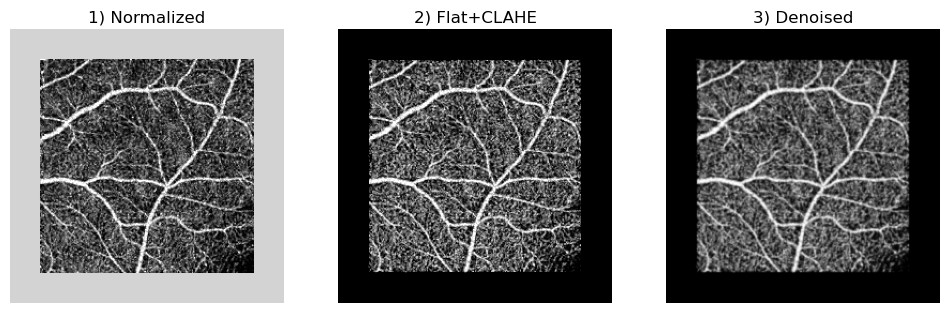

In [20]:
from pathlib import Path
import cv2, numpy as np
from skimage import io, img_as_float32
import matplotlib.pyplot as plt
# Chargement du patch (png)
PATCH_PATH = OUT_DIR / "00001.png" 
patch = io.imread(str(PATCH_PATH))
if patch.ndim == 3:                 
    patch = patch[...,0]
img = img_as_float32(patch) 

# Étape 1–3 : prétraitements
img = normalize01_array(img)
pre = flatten_and_clahe(img, tophat_radius_frac=1/25, clahe_clip=0.005, tiles=8)
den = denoise_light(pre, method="median")

fig, axs = plt.subplots(1,3, figsize=(12,4))
axs[0].imshow(img, cmap='gray'); axs[0].set_title("1) Normalized"); axs[0].axis('off')
axs[1].imshow(pre, cmap='gray'); axs[1].set_title("2) Flat+CLAHE"); axs[1].axis('off')
axs[2].imshow(den, cmap='gray'); axs[2].set_title("3) Denoised"); axs[2].axis('off')
plt.show()

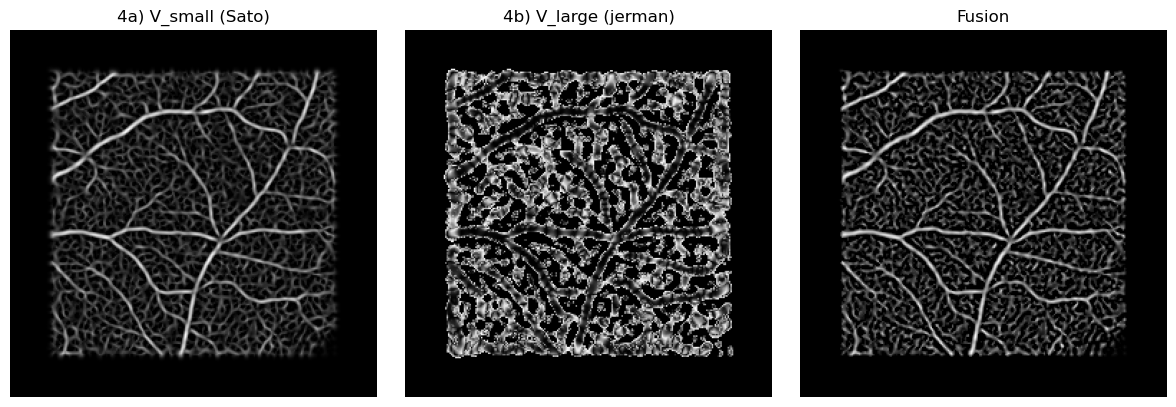

In [22]:
# Étape 4 : vesselness dual-band
V_meij_fine = vesselness(den, method="sato", sigmas=(0.6*SCALE, 1.6*SCALE), bright=True)
V_meij_mid  = vesselness(den, method="meijering", sigmas=(0.6*SCALE, 1.6*SCALE), bright=True)
# V_small     = np.maximum(V_meij_fine, 0.7*V_meij_mid) 
V_large = vesselness(den, method=LARGE_METHOD,  sigmas=SIG_LARGE, bright=True)
V_fused = 0.8*V_meij_fine + 0.2*V_meij_mid
fig, axs = plt.subplots(1,3, figsize=(12,4))
axs[0].imshow(V_meij_fine, cmap='gray'); axs[0].set_title("4a) V_small (Sato)"); axs[0].axis('off')
axs[1].imshow(V_large, cmap='gray'); axs[1].set_title(f"4b) V_large ({LARGE_METHOD})"); axs[1].axis('off')
axs[2].imshow(V_meij_mid, cmap='gray', vmin=0, vmax=1); axs[2].set_title("Fusion");    axs[2].axis('off')
plt.tight_layout(); plt.show()


In [23]:
from pathlib import Path
label_capillaries(
    preproc_root=Path(r"D:\projet PRIM\data\preproc_batch_3mm"),
    out_dir=Path(r"D:\projet PRIM\data\label")
)